# TFLite MoveNet:  Lightning Pose Estimation 

# 1. Importazione e installazione delle dipendenze

In [1]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [2]:
!pip install tensorflow opencv-python numpy psutil pandas openpyxl matplotlib

  Using cached tensorflow-2.21.0-cp310-cp310-macosx_12_0_arm64.whl.metadata (4.4 kB)
  Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
Using cached tensorflow-2.21.0-cp310-cp310-macosx_12_0_arm64.whl (223.2 MB)
Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl (429 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.9
    Uninstalling protobuf-4.25.9:
      Successfully uninstalled protobuf-4.25.9
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorflow] 1/2 [tensorflow]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 7.34.1 which is incompatible.


In [1]:
import tensorflow as tf 
import cv2 
import numpy as np
import psutil 
import os 
import time
import glob 
import platform 
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponibili: {tf.config.list_physical_devices('GPU')}")
print(f"CPU: {platform.processor()}")
print(f"RAM totale: {psutil.virtual_memory().total / 1e9:.1f} GB")

TensorFlow version: 2.21.0
GPU disponibili: []
CPU: arm
RAM totale: 8.6 GB


# 2. Edges
- Stabiliamo i vari "spigoli" che caratterizzano lo scheletro della pose detection.
- Sono riportate nei testi ufficiali tutte le corrispondenze legate ad ognuno di essi.

In [3]:
EDGES = {
    (0, 1): 'm',
    (0, 2): 'c',
    (1, 3): 'm',
    (2, 4): 'c',
    (0, 5): 'm',
    (0, 6): 'c',
    (5, 7): 'm',
    (7, 9): 'm',
    (6, 8): 'c',
    (8, 10): 'c',
    (5, 6): 'y',
    (5, 11): 'm',
    (6, 12): 'c',
    (11, 12): 'y',
    (11, 13): 'm',
    (13, 15): 'm',
    (12, 14): 'c',
    (14, 16): 'c'
}

# 3. Funzioni per la creazione dello scheletro
- `draw_connections`: sfrutta il dizionario EDGES e traccia le linee che definiscono lo scheletro
- `draw_keypoints`: accentua i punti salienti dello scheletro seguendo di pari passo i possibili movimenti delle connessioni. Nei documenti ufficiali sono listate le corrispondenze per ciascun keypoint. 

In [4]:
def draw_connections(frame, keypoints, edges, confidence_threshold):
    y, x, c = frame.shape
    shaped = np.squeeze(np.multiply(keypoints, [y,x,1]))
    
    for edge, color in edges.items():
        p1, p2 = edge
        y1, x1, c1 = shaped[p1]
        y2, x2, c2 = shaped[p2]
        
        if (c1 > confidence_threshold) & (c2 > confidence_threshold):      
            cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0,0,255), 2)

In [5]:
def draw_keypoints(frame, keypoints, confidence_threshold): 
    y, x, c = frame.shape
    shaped = np.squeeze(np.multiply(keypoints, [y,x,1]))

    for kp in shaped: 
        ky, kx, kp_conf = kp
        if kp_conf > confidence_threshold: 
            cv2.circle(frame, (int(kx), int(ky)), 4, (0,255,0), -1)

# 4. Rendering dello scheletro su sfondo nero 
- Richiamando le funzioni `draw_connections` e `draw_keypoints` renderizziamo un secondo scheletro, copia del primo all'interno di uno sfondo nero dimensionalmente uguale al frame principale 

In [6]:
def render_skeleton(frame, keypoints, edges, confidence_threshold):

    black_screen = np.zeros(frame.shape, dtype=np.uint8)
    
    draw_connections(black_screen, keypoints, edges, confidence_threshold)
    draw_keypoints(black_screen, keypoints, confidence_threshold)
  
    return black_screen

## 5. Pre-processing
Convertiamo il frame grezzo nel tensore atteso dal modello:
- `BGR → RGB`: poiché OpenCV legge in BGR e il modello si aspetta un ritorno in RGB, convertiamo la scala di colori.
- Eseguiamo un resize a `192×192` (dimensione di input del modello TFLite)
- Cast a `float32` + `expand_dims` per aggiungere la dimensione batch → shape `[1, 192, 192, 3]`

In [7]:
def pre_processing(frame):
    # BGR → RGB
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    # Eseguiamo ridimensionamento dell'img
    img = cv2.resize(img_rgb, (192, 192))
    # Conversione di tipo (cast) + espansione delle dimensioni → forma [1, 192, 192, 3]
    input_image = tf.cast(np.expand_dims(img, axis=0), dtype=tf.float32)
    return input_image

## 6. Inferenze
Passiamo il tensore al modello TFLite che restituirà i 17 keypoint con score.
- Output shape: `[1, 1, 17, 3]` dove ogni keypoint è `[y_norm, x_norm, confidence]`
- Le coordinate sono **normalizzate** in `[0, 1]` — vengono denormalizzate nel rendering

In [8]:
def make_detections(interpreter, input_image):
    # Configuriamo input e output
    input_details  = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Effetuiamo rilevamenti
    interpreter.set_tensor(input_details[0]['index'], np.array(input_image))
    interpreter.invoke()
    keypoints_with_scores = interpreter.get_tensor(output_details[0]['index'])
    return keypoints_with_scores


## 7. Post-processing
Filtriamo i keypoint sotto la soglia di confidenza e calcoliamo:
- **`conf_mean`**: confidenza media su tutti i 17 keypoint → proxy dell'accuratezza del rilevamento
- **`jitter`**: distanza media tra la posizione dei keypoint al frame `t` e al frame `t-1`, consentendo di misurare la stabilità del tracking

In [9]:
def post_processing(keypoints_with_scores, prev_keypoints_with_scores=None, confidence_threshold=0.3):
    shaped = np.squeeze(keypoints_with_scores)   # shape: (17, 3)

    # Numero keypoint rilevati sopra soglia
    n_detected = int((shaped[:, 2] > confidence_threshold).sum())

    # Confidenza media (proxy accuratezza)
    conf_mean = round(float(shaped[:, 2].mean()), 4)

    # Jitter: distanza media rispetto al frame precedente (proxy stabilità)
    if prev_keypoints_with_scores is not None:
        prev_shaped = np.squeeze(prev_keypoints_with_scores)
        jitter = round(float(np.abs(shaped[:, :2] - prev_shaped[:, :2]).mean()), 4)
    else:
        jitter = 0.0

    return {
        'n_detected': n_detected,
        'conf_mean':  conf_mean,
        'jitter':     jitter,
    }

## 8. Rendering finale
Combiniamo il frame principale con il frame con sfondo nero tramite la funzione `np.hstack`.

In [10]:
def rendering(frame, keypoints_with_scores, fps, cpu_usage, ram_usage, run, video_name):
   
    draw_connections(frame, keypoints_with_scores, EDGES, 0.3)
    draw_keypoints(frame, keypoints_with_scores, 0.3)

    skeleton = render_skeleton(frame, keypoints_with_scores, EDGES, 0.3)

    combined_frames = np.hstack((frame, skeleton))

    # cv2.putText per visualizzare i dati nel video
    cv2.putText(combined_frames, f"CPU: {cpu_usage}%",           (10,  30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(combined_frames, f"RAM: {ram_usage:.1f} MB",      (10,  70), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(combined_frames, f"FPS: {int(fps)}",              (10, 110), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(combined_frames, f"Video: {video_name[:15]}...",  (10, 150), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)
    cv2.putText(combined_frames, f"Run: {run+1}/2",               (10, 190), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    return combined_frames

## 9. Raccolta metriche
Raccoglie tutte le metriche del frame in un dizionario. 
Ogni chiamata produce una riga dell'Excel finale.

In [11]:
def collect_metrics(video_name, run, frame_count, fps, cpu_usage, ram_usage, post_data):
    return {
        "Video name":    video_name,
        "Execution":     run + 1,
        "Frame N":       frame_count,
        "CPU (%)":       cpu_usage,
        "RAM (MB)":      round(ram_usage, 2),
        "FPS":           round(fps, 2),
        "Confidence":    post_data['conf_mean'],
        "Keypoints det": post_data['n_detected'],
        "Jitter":        post_data['jitter'],
    }

# 10. Main (Fase di detection)

In [12]:
video_folder = "/Users/rebeccaspigacortes/Desktop/data_set_singolo" #video_folder cartella che contiene tutti i video
video_paths = sorted(glob.glob(video_folder + "/*.mp4"))
print(f"Video trovati nel dataset: {len(video_paths)}")  
assert len(video_paths) > 0, f"Nessun .mp4 trovato in: {video_folder}"

interpreter = tf.lite.Interpreter(model_path='3.tflite')
interpreter.allocate_tensors()
process = psutil.Process(os.getpid())

project_data = []

#video_path è il singolo video corrente 
for video_path in video_paths:
    video_name = os.path.basename(video_path)
    print(f"\n{'='*40}")
    print(f"Processo: {video_name}")
    
    # Doppio ciclo
    for run in range(2):
        print(f"Sto riproducendo: {video_name} | Esecuzione: {run + 1}/2")

        cap         = cv2.VideoCapture(video_path)  # Se vogliamo utilizzare la webcam: cv2.VideoCapture(0)
        frame_count = 0    # azzerato ad ogni run
        prev_time   = 0
        prev_keypoints_with_scores = None  # per il calcolo del jitter

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break  # Se il video finisce, esce dal while
            frame_count += 1

            # Per l'utilizzo della CPU e la RAM
            cpu_usage = psutil.cpu_percent()
            ram_usage = process.memory_info().rss / (1024 * 1024)

            # FPS
            curr_time = time.perf_counter()
            if prev_time != 0:
                frame_time = curr_time - prev_time
                fps = 1 / frame_time
            else:
                fps = 0
            prev_time = curr_time

            # Utilizziamo le funzioni definite separatamente
            input_image            = pre_processing(frame)                                          # Stage 1
            keypoints_with_scores  = make_detections(interpreter, input_image)                      # Stage 2
            post_data              = post_processing(keypoints_with_scores,                         # Stage 3
                                                 prev_keypoints_with_scores)
            combined_frames        = rendering(frame, keypoints_with_scores,                        # Stage 4
                                           fps, cpu_usage, ram_usage, run, video_name)
            project_data.append(collect_metrics(video_name, run, frame_count,                      # Stage 5
                                            fps, cpu_usage, ram_usage, post_data))
       
            prev_keypoints_with_scores = keypoints_with_scores  # salva per il jitter al prossimo frame

            # print per vedere i risultati nella CONSOLE
            print(f"CPU: {cpu_usage}% | RAM: {ram_usage:.2f}MB | FPS: {fps:.1f}")

            cv2.imshow('Pose Detection: Original and Skeleton rendering', combined_frames)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

        cap.release()
        cv2.destroyAllWindows()

Video trovati nel dataset: 21

Processo: 01-jumping-lady.mp4
Sto riproducendo: 01-jumping-lady.mp4 | Esecuzione: 1/2


/Users/rebeccaspigacortes/miniconda3/envs/tensor_flow/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


CPU: 6.5% | RAM: 706.05MB | FPS: 0.0
CPU: 37.0% | RAM: 964.95MB | FPS: 1.7
CPU: 44.5% | RAM: 1027.97MB | FPS: 4.9
CPU: 0.0% | RAM: 1051.22MB | FPS: 6.0
CPU: 34.8% | RAM: 1062.69MB | FPS: 5.6
CPU: 30.2% | RAM: 1063.17MB | FPS: 6.8
CPU: 24.6% | RAM: 1055.69MB | FPS: 6.8
CPU: 0.0% | RAM: 1046.27MB | FPS: 6.9
CPU: 0.0% | RAM: 1053.23MB | FPS: 7.4
CPU: 0.0% | RAM: 1024.05MB | FPS: 6.9
CPU: 0.0% | RAM: 1056.62MB | FPS: 6.9
CPU: 23.8% | RAM: 1060.97MB | FPS: 7.1
CPU: 23.0% | RAM: 1061.12MB | FPS: 7.0
CPU: 43.4% | RAM: 1046.42MB | FPS: 6.5
CPU: 23.3% | RAM: 1062.89MB | FPS: 6.8
CPU: 24.8% | RAM: 1066.83MB | FPS: 6.9
CPU: 22.8% | RAM: 1067.06MB | FPS: 6.9
CPU: 23.9% | RAM: 1067.66MB | FPS: 7.0
CPU: 21.1% | RAM: 1068.03MB | FPS: 6.8
CPU: 20.2% | RAM: 1070.11MB | FPS: 7.0
CPU: 23.0% | RAM: 1071.30MB | FPS: 6.9
CPU: 0.0% | RAM: 1071.33MB | FPS: 7.1
CPU: 0.0% | RAM: 1071.73MB | FPS: 7.0
CPU: 0.0% | RAM: 1072.89MB | FPS: 7.1
CPU: 0.0% | RAM: 1074.28MB | FPS: 7.0
CPU: 0.0% | RAM: 1074.31MB | FPS: 7.0

# 11. Export dati → Excel
Salva `project_data` in un file `.xlsx`.

In [13]:
df = pd.DataFrame(project_data)

excel_name = f"results_tflite_{platform.node()}.xlsx"
df.to_excel(excel_name, index=False)

print(f"Salvato: {excel_name}")
print(df.describe().round(3))

Salvato: results_tflite_MACBOOKAIR-2547.station.xlsx
       Execution    Frame N    CPU (%)   RAM (MB)        FPS  Confidence  \
count    15030.0  15030.000  15030.000  15030.000  15030.000   15030.000   
mean         1.5    199.329      8.216    593.144     16.240       0.406   
std          0.5    138.402     11.116    152.098      4.335       0.147   
min          1.0      1.000      0.000    428.440      0.000       0.011   
25%          1.0     90.000      0.000    497.110     11.820       0.335   
50%          1.5    179.000      0.000    540.760     16.510       0.415   
75%          2.0    271.750     19.400    628.520     17.640       0.504   
max          2.0    577.000     74.100   1119.860     28.540       0.761   

       Keypoints det     Jitter  
count      15030.000  15030.000  
mean          12.041      0.025  
std            4.970      0.060  
min            0.000      0.000  
25%           10.000      0.004  
50%           14.000      0.009  
75%           16.000    

# 12. Analisi stabilità tra i due run
Confronta le metriche medie del run 1 e del run 2.
Un modello stabile produce valori simili in entrambe le esecuzioni sullo stesso video.

In [14]:
summary = df.groupby("Execution")[["FPS", "CPU (%)", "RAM (MB)",
                                    "Confidence", "Jitter"]].mean().round(3)
print(summary)
print("\nDelta run1 vs run2:")
print((summary.loc[2] - summary.loc[1]).round(3))

              FPS  CPU (%)  RAM (MB)  Confidence  Jitter
Execution                                               
1          16.221    8.123   597.514       0.406   0.025
2          16.259    8.308   588.775       0.406   0.025

Delta run1 vs run2:
FPS           0.038
CPU (%)       0.185
RAM (MB)     -8.739
Confidence    0.000
Jitter        0.000
dtype: float64


# 13. Cella di RIEPILOGO

In [15]:
print(f"{'='*40}")
print(f"RIEPILOGO ESECUZIONE")
print(f"{'='*40}")
print(f"Video processati:        {df['Video name'].nunique()}")
print(f"Frame totali analizzati: {len(df)}")
print(f"Esecuzioni per video:    {df['Execution'].max()}")
print(f"Frame totali (run x2):   {len(df)}")
print(f"\nVideo inclusi nel test:")
for v in sorted(df['Video name'].unique()):
    n_frames = len(df[df['Video name'] == v]) // int(df['Execution'].max())
    print(f"  - {v}  ({n_frames} frame/run)")

RIEPILOGO ESECUZIONE
Video processati:        21
Frame totali analizzati: 15030
Esecuzioni per video:    2
Frame totali (run x2):   15030

Video inclusi nel test:
  - 01-jumping-lady.mp4  (250 frame/run)
  - 02-running-lady.mp4  (290 frame/run)
  - 03-slam-guy.mp4  (267 frame/run)
  - 04-football-guy.mp4  (290 frame/run)
  - 05-warm-up-lady.mp4  (302 frame/run)
  - 06-kpop-cover.mp4  (301 frame/run)
  - 07-workout1.mp4  (577 frame/run)
  - 08-workout2.mp4  (569 frame/run)
  - 09-muay-thai-lady.mp4  (241 frame/run)
  - 10-shadow-box.mp4  (284 frame/run)
  - 11-skill.mp4  (304 frame/run)
  - 12-gym-girl.mp4  (276 frame/run)
  - 13-swim.mp4  (543 frame/run)
  - 14-skill2.mp4  (301 frame/run)
  - 15-roller.mp4  (302 frame/run)
  - 16-multipose1.mp4  (301 frame/run)
  - 17-multipose2.mp4  (290 frame/run)
  - 18-multipose3.mp4  (574 frame/run)
  - 19-multipose4.mp4  (572 frame/run)
  - 20-multipose5.mp4  (322 frame/run)
  - 21-extra.mp4  (359 frame/run)


# 14. Grafici

Creiamo due grafici: 
- **metrics_mean_overview.png**
  > mostrerà la media per video di FPS, CPU, RAM, Confidence e
    Jitter, attraverso un grafico a barre per ogni metrica. Sarà utile per
    confrontare le prestazioni del modello sui diversi video.

- **run_comparison.png**
  > confronterà i valori medi del Run 1 e Run 2 per ogni metrica, in un              grafico a barre. Sarà utile per verificare la stabilità del modello tra le       due esecuzioni 

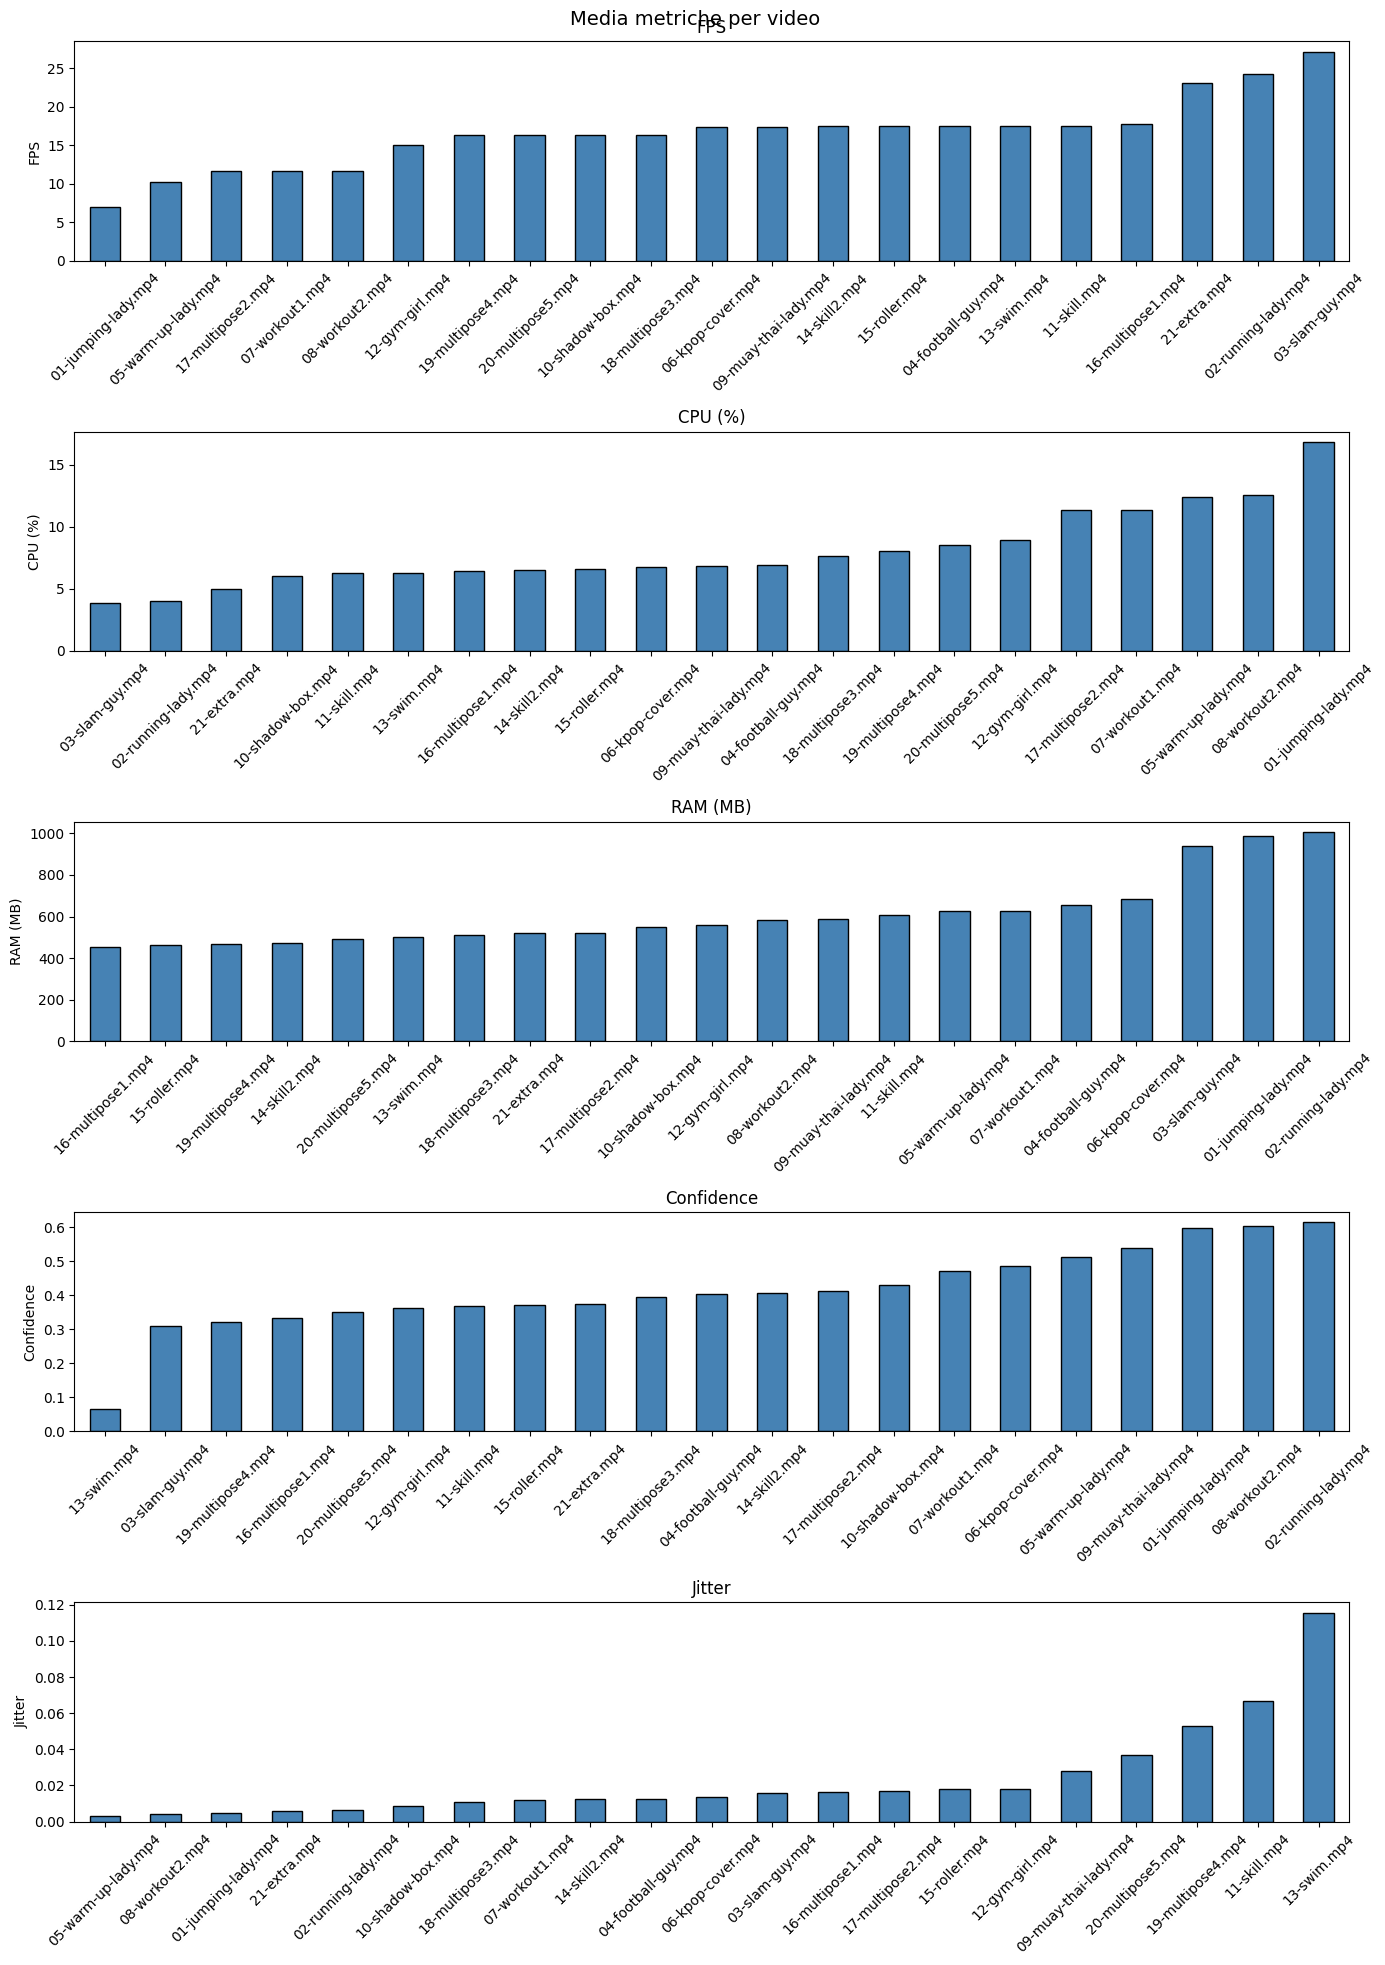

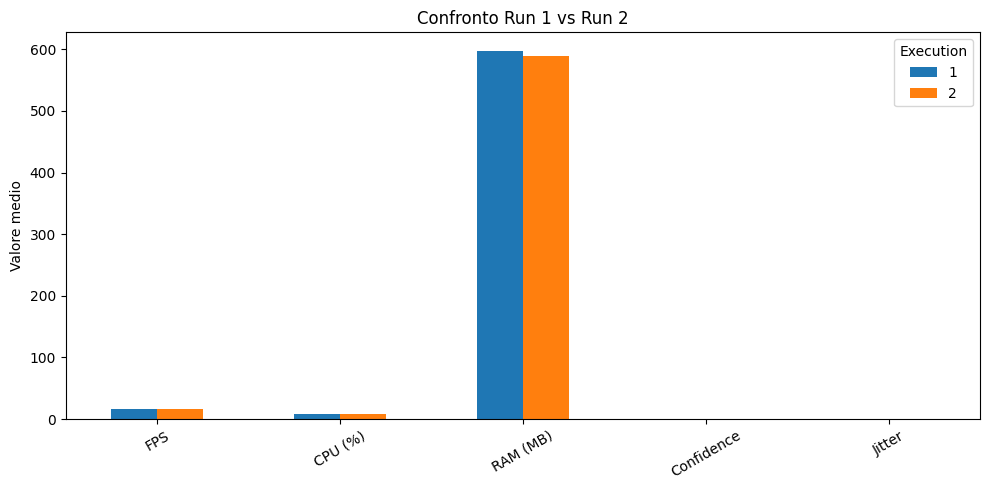

In [16]:
metrics = ['FPS', 'CPU (%)', 'RAM (MB)', 'Confidence', 'Jitter']

fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 4 * len(metrics)))
fig.suptitle("Media metriche per video", fontsize=14)

for ax, metric in zip(axes, metrics):
    means = df.groupby('Video name')[metric].mean().sort_values()
    means.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("metrics_mean_overview.png", dpi=150, bbox_inches='tight')
plt.show()

# Grafico 2: confronto Run 1 vs Run 2
summary = df.groupby("Execution")[metrics].mean().round(3)

summary.T.plot(kind="bar", figsize=(10, 5), title="Confronto Run 1 vs Run 2")
plt.ylabel("Valore medio")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("run_comparison.png", dpi=150)
plt.show()